# ROOT Histograms and the Unified Histogram Interface (UHI)

## 🎯 Learning Objectives

At the beginning of this course you should already be familiar with:
* Creating, filling and drawing histograms
* Fitting functions 
* Drawing graphs
* Making histogram stacks and efficiency curves

By the end of this notebook, you will be able to:

* **Use UHI syntax** to access and set bin contents, slice, rebin and project histograms
* **Visualise** ROOT histograms using common Python plotting libraries

## ✅ Environment Check

UHI support requires **ROOT ≥ 6.36**.

In [1]:
import ROOT

print(f"ROOT version: {ROOT.gROOT.GetVersion()}")

assert ROOT.gROOT.GetVersionInt() >= 63600, (
    "ROOT >= 6.36 is required for UHI support. You can still run the Projections section, but skip the UHI cells."
)

ROOT version: 6.38.04


---
## 🧱 ROOT Histograms: Quick Recap

[Histogram class documentation](https://root.cern.ch/doc/master/classTH1.html)

ROOT histogram objects let you produce complex plots and perform fits of arbitrary functions.
Below is an example output from the [Higgs to Four Leptons](https://root.cern/doc/master/df106__HiggsToFourLeptons_8py.html) tutorial.

Common types:
- `TH1D`: 1D histogram, double-precision y-axis
- `TH2D`: 2D histogram, double-precision z-axis  
- `TH2I`: 2D histogram, integer z-axis

<center><img src="../images/examplehist_df106_HiggsToFourLeptons.png"></center>

In [2]:
# Simple 1D histogram with Gaussian distribution
h1d_gaus = ROOT.TH1D(name="h1d_gaus", title="My histo", nbinsx=100, xlow=-5, xup=5)
h1d_gaus.FillRandom("gaus", ntimes=5000)

%jsroot on
c = ROOT.TCanvas()
h1d_gaus.Draw()
c.Draw()

---
## 🎯 Projections

Often, we want to study how one variable behaves while **integrating over the others**.
ROOT provides projection methods that extract lower-dimensional histograms from higher-dimensional ones.

See [Projections of histograms](https://root.cern.ch/doc/v636/classTH1.html#prof-hist) for more details.

Here we will:
- Fill a 2D histogram with Gaussian-distributed data
- Compute and draw its projections along **X** and **Y** using native ROOT methods

Later, in the UHI section, we will see how to achieve the same thing with a more Pythonic syntax

In [3]:
from ROOT import gRandom

# Create a 2D histogram
h2d_gaus = ROOT.TH2D("h2d_gaus", "2D Gaussian;X;Y", 25, -5, 5, 50, -5, 5)

# Fill with Gaussian-distributed data
for i in range(50000):
    x = gRandom.Gaus(0, 1)
    y = gRandom.Gaus(0, 1)
    h2d_gaus.Fill(x, y)

# Compute projections using native ROOT methods
# ProjectionX collapses the Y axis -> gives a 1D histogram in X
# ProjectionY collapses the X axis -> gives a 1D histogram in Y
hpx = h2d_gaus.ProjectionX("hpx")
hpy = h2d_gaus.ProjectionY("hpy")

In [4]:
# Draw the 2D histogram and both projections side by side
c_proj = ROOT.TCanvas("c_proj", "2D Gaussian and Projections", 1000, 400)
c_proj.Divide(2, 1)
c_proj.cd(1)
h2d_gaus.Draw("COLZ")

c_proj.cd(2)
hpx.SetLineColor(ROOT.kBlue)
hpy.SetLineColor(ROOT.kRed)
hpx.SetTitle("Projections;Value;Entries")
hpx.Draw()
hpy.Draw("SAME")

c_proj.Draw()

---
## 🧩 The Unified Histogram Interface (UHI)

### Why does UHI exist?

The scientific Python ecosystem has many histogram libraries: ROOT, `numpy`, `boost-histogram`, `hist`, and more, each with its own API.

**UHI** ([documentation](https://uhi.readthedocs.io/en/latest/)) is a **common interface standard** that all compliant libraries implement. It means:

- You can slice, project and rebin any UHI-compliant histogram with the **same syntax**
- ROOT histograms plug directly into Python plotting tools like `mplhep` with no manual conversion
- Code you write for ROOT histograms largely works unchanged on `boost-histogram` objects, and vice-versa

> Think of it as an **adapter layer**: UHI doesn't change the underlying ROOT implementation, it just exposes a Pythonic face on top of it.

> **Reminder:** ROOT ≥ 6.36 is required for the cells below.

In [5]:
from ROOT.uhi import loc, overflow, rebin, sum, underflow
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import seaborn as sns

### 🔑 UHI tags Glossary

UHI introduces a small set of special tags used inside `[]` to express operations on histograms. Here is what each one means before we use them:

| Token | Meaning |
|---:|:---|
| `...` (Ellipsis) | **All bins**, including underflow and overflow. `h[...] = values` sets every bin at once. |
| `underflow` | The **underflow bin**: counts that fell below the axis range. |
| `overflow` | The **overflow bin**: counts that fell above the axis range. |
| `loc(x)` | Select by **data coordinate** `x`, not by bin index. |
| `rebin(n)` | **Merge** every `n` consecutive bins into one. |
| `sum` | **Collapse** an axis by summing over it, equivalent to a projection. |

The general slice syntax is: `histogram[start:stop:action]`


Separate axes with commas: `histogram2d[x_start:x_stop:x_action, y_start:y_stop:y_action]`

### Fill vs SetBinContent

Before we use UHI-style setting, it is important to understand the difference between **filling** and **setting** a histogram, as they are easy to confuse:

In [6]:
h_fill_set = ROOT.TH1D("h", "Fill vs SetBinContent", 3, 0, 3)

# Fill() -> interprets the argument as a DATA VALUE and increments the matching bin
h_fill_set.Fill(2.5)  # data value 2.5 falls in the last bin
print("After Fill(2.5):", h_fill_set.values())

# SetBinContent() -> directly writes a NUMBER into a specific bin slot
h_fill_set.Reset()
h_fill_set.SetBinContent(1, 2.5)  # bin index 1 gets the value 2.5
print("After SetBinContent(1, 2.5):", h_fill_set.values())

After Fill(2.5): [0. 0. 1.]
After SetBinContent(1, 2.5): [2.5 0.  0. ]


### Setting bin contents with UHI

UHI lets you assign to a whole histogram at once using the `[...]` (Ellipsis) syntax.  
`[...]` means **all bins including underflow and overflow**, so the array you pass must have length `nbins`, or length `nbins + 2` if you want to fill the flow bins.

In [7]:
h1d_uhi_basic = ROOT.TH1D(name="h1d_uhi_basic", title="My UHI histo", nbinsx=10, xlow=0, xup=1)

# [...]  means: all bins including underflow (index 0) and overflow (index 11)
# np.linspace(0, 11, 12) produces [0, 1, 2, ..., 11], 12 values for 10 bins + 2 flow bins
h1d_uhi_basic[...] = np.linspace(0, 11, 12)

# Equivalent native ROOT-style loop:
# values = np.linspace(0, 11, 12)
# for i in range(0, h1d_uhi_basic.GetNbinsX() + 2):  # +2 for under/overflow
#     h1d_uhi_basic.SetBinContent(i, values[i])

print(f"Bin contents (no flow): {h1d_uhi_basic.values()}")
print(f"Underflow bin: {h1d_uhi_basic[underflow]}")
print(f"Overflow bin: {h1d_uhi_basic[overflow]}")

Bin contents (no flow): [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Underflow bin: 0.0
Overflow bin: 11.0


### 💡 UHI ↔ ROOT Cheat Sheet (Bin Access)

| **UHI Expression**   | **Equivalent ROOT**              | **Description**                     |
|---------------------:|:---------------------------------|:------------------------------------|
| `h[...]`             | (loop over all bins)             | Access all bins incl. flow          |
| `h[i] = value`       | `h.SetBinContent(i+1, value)`    | Set content of bin `i`              |
| `h[i]`               | `h.GetBinContent(i+1)`           | Get content of bin `i`              |
| `h[underflow]`       | `h.GetBinContent(0)`             | Underflow bin                       |
| `h[overflow]`        | `h.GetBinContent(nbins+1)`       | Overflow bin                        |

!!! histogram déjà conforme au protocole !!!


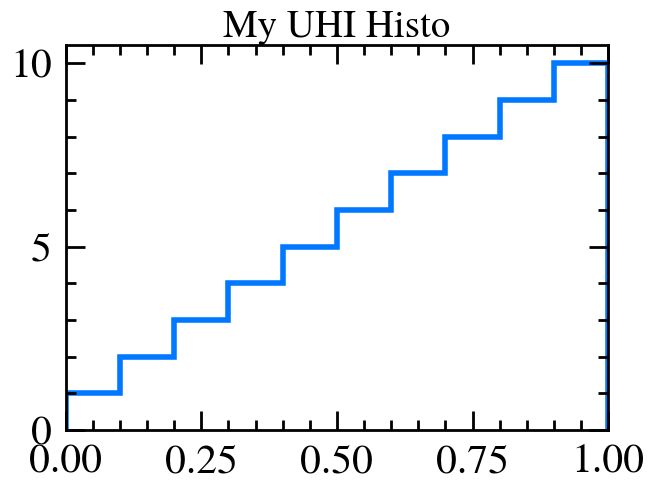

In [8]:
hep.style.use("LHCb2")

plt.figure(figsize=(7, 5))
hep.histplot(h1d_uhi_basic, yerr=False, linewidth=4)
plt.title("My UHI Histo")
plt.show()

### 📝 Exercise 1: Fill and plot a Gaussian histogram

Using [`np.histogram`](https://numpy.org/doc/2.1/reference/generated/numpy.histogram.html), create a ROOT `TH1D` that matches the distribution of `h1d_gaus` (100 bins, range −5 to 5, 5000 entries drawn from a standard normal).

Then plot it with `mplhep` and add a text box showing **Entries**, **Mean** and **Std Dev** (like ROOT's default stats box).

> 💡 Hint: `np.histogram` returns `(counts, bin_edges)`. You only need the counts to fill the histogram.

!!! histogram déjà conforme au protocole !!!


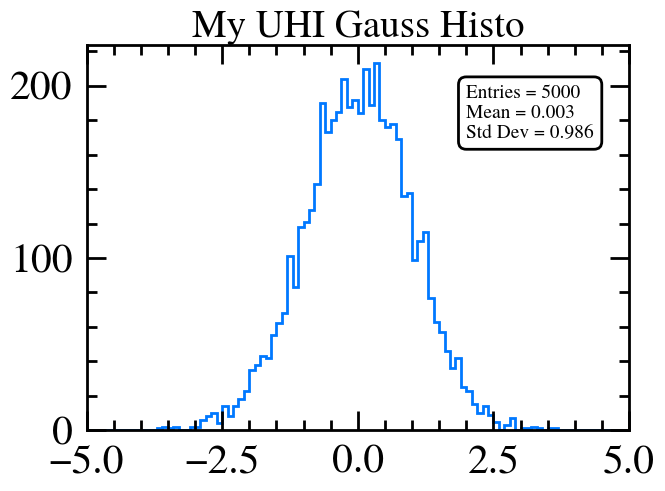

In [ ]:
# Your code here

<details>
<summary><b>Click to show solution</b></summary>

<pre>
h1d_uhi_gauss = ROOT.TH1D(name="h1d_uhi_gauss", title="My UHI Gauss", nbinsx=100, xlow=-5, xup=5)
h1d_uhi_gauss[...] = np.histogram(np.random.normal(size=5000), bins=100, range=(-5, 5))[0]

entries = h1d_uhi_gauss.GetEntries()
mean = h1d_uhi_gauss.GetMean()
std = h1d_uhi_gauss.GetStdDev()

plt.figure(figsize=(7, 5))
hep.histplot(h1d_uhi_gauss, linewidth=2, yerr=False)
plt.title("My UHI Gauss Histo")
plt.text(
    2, 170,
    f"Entries = {entries:.0f}\nMean = {mean:.3f}\nStd Dev = {std:.3f}",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white")
)
plt.show()
</pre>
</details>

---
## 🔪 UHI Slicing, Rebinning and Projections

UHI's most powerful feature is its **slice syntax**, which lets you transform histograms in one line using familiar Python bracket notation:

```python
histogram1d[start:stop:action]
histogram2d[start:stop:action, start:stop:action]
```

Below we build a 2D histogram, then explore the key operations.

In [10]:
h2d = ROOT.TH2D("h2d", "", 40, -4, 4, 40, -20, 20)

h2d[...] = np.histogram2d(
    np.random.normal(0, 1, 25000),
    5 * np.random.normal(0, 1, 25000),
    bins=(40, 40),
    range=[[-4, 4], [-20, 20]]
)[0]

### Projections via `sum`

`::sum` in a slice position means: **collapse this entire axis by summing** all bins along it.

```python
h2d[::sum, :] # sum over X  -->  1D histogram in Y
h2d[:, ::sum] # sum over Y  --> 1D histogram in X
```

### Rebinning via `rebin(n)`

`::rebin(n)` merges every `n` consecutive bins into one.

### Location-based slicing via `loc(x)`

`loc(x)` selects by **data coordinate** rather than bin index.  
For the ROOT equivalent, you would need to compute the bin number using `FindBin(x)`.

In [11]:
projh2X = h2d[::sum, :] # collapse X axis --> 1D in Y
projh2Y = h2d[:, ::sum] # collapse Y axis --> 1D in X

projh2X_rebinned = projh2X[::rebin(5)] # merge 5 bins into 1
projh2X_sliced = projh2X[loc(0):] # keep only values >= 0 (data coordinate)

### 💡 UHI ↔ ROOT Cheat Sheet (Slicing Operations)

| **UHI Expression**    | **Equivalent ROOT**           | **Description**                         |
|----------------------:|:------------------------------|:----------------------------------------|
| `h2[::sum, :]`        | `h2.ProjectionY()`            | Projection onto the **Y** axis          |
| `h2[:, ::sum]`        | `h2.ProjectionX()`            | Projection onto the **X** axis          |
| `h1[::rebin(2)]`      | `h1.Rebin(2)`                 | Rebin by a factor of 2                  |
| `h1[loc(a):loc(b)]`   | ❌ *(use`FindBin`)* | Slice between data values `a` and `b`   |

### 🔍 Verifying UHI ↔ ROOT Equivalence

A natural question: does `h2d[:, ::sum]` really give the same result as `h2d.ProjectionX()`?  
Let's check numerically:

In [12]:
# Native ROOT projection
projh2Y_root = h2d.ProjectionX("projh2Y_root")

# UHI projection
projh2Y_uhi = h2d[:, ::sum]

# Compare bin values
root_vals = np.array([projh2Y_root.GetBinContent(i) for i in range(1, projh2Y_root.GetNbinsX() + 1)])
uhi_vals = projh2Y_uhi.values()

are_equal = np.allclose(root_vals, uhi_vals)
print(f"ROOT ProjectionX == UHI [:, ::sum] : {are_equal}")

ROOT ProjectionX == UHI [:, ::sum] : True


!!! histogram déjà conforme au protocole !!!
!!! histogram déjà conforme au protocole !!!
!!! histogram déjà conforme au protocole !!!
!!! histogram déjà conforme au protocole !!!
!!! histogram déjà conforme au protocole !!!


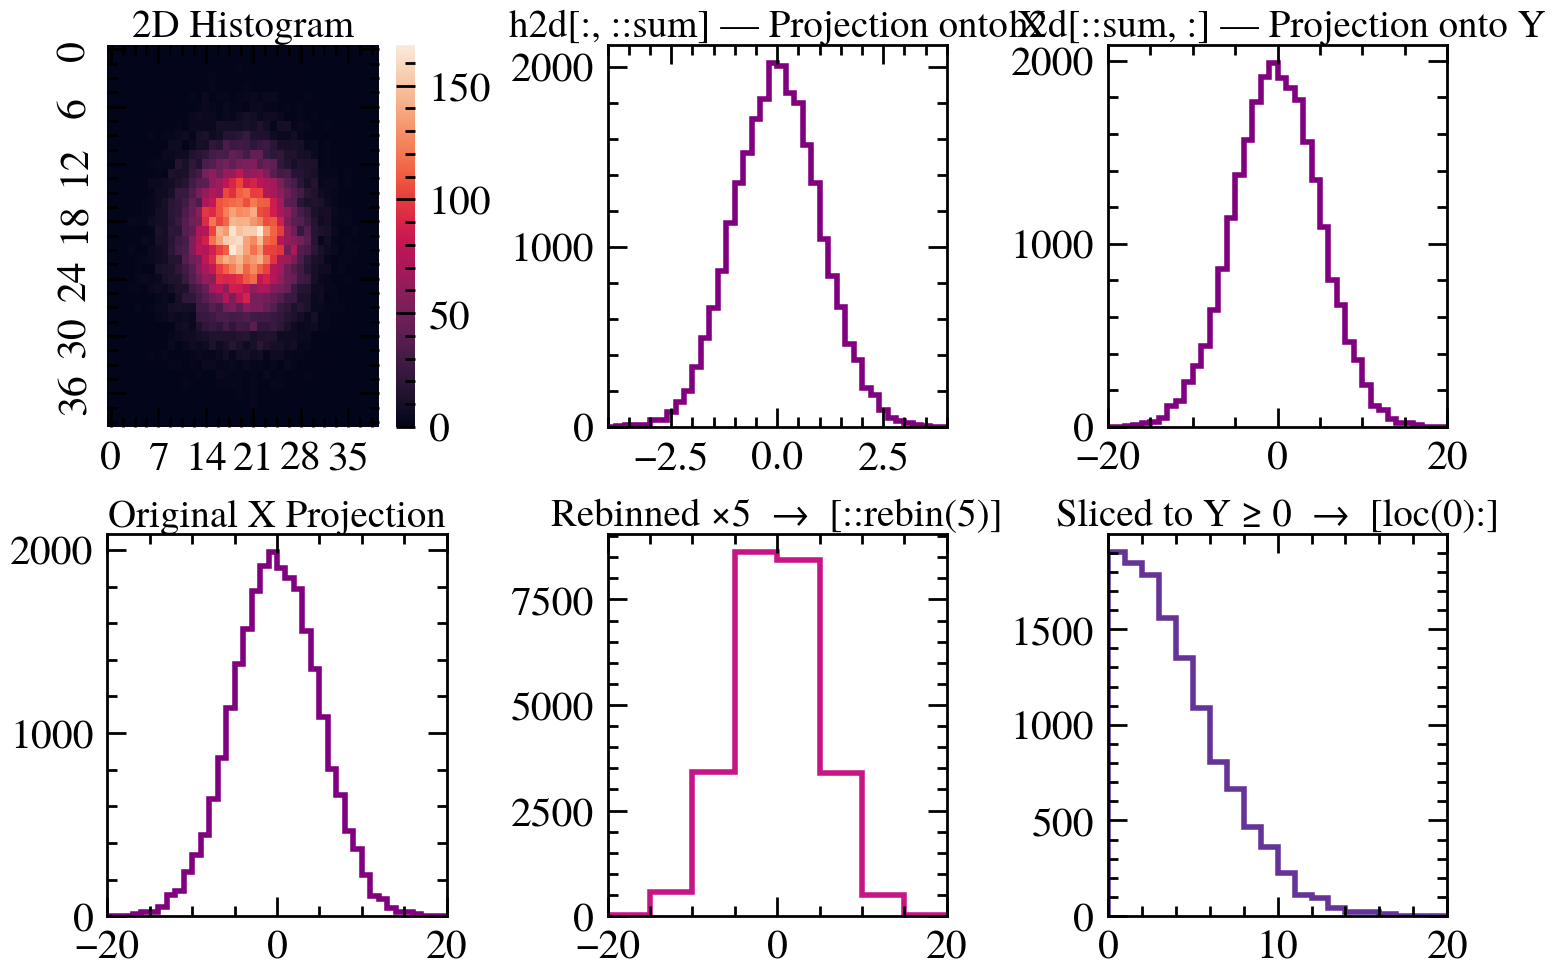

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: 2D histogram + projections
sns.heatmap(h2d.values(), ax=axes[0, 0], cbar=True)
axes[0, 0].set_title("2D Histogram")

hep.histplot(projh2Y, ax=axes[0, 1], histtype="step", color="purple", linewidth=4, yerr=False)
axes[0, 1].set_title("h2d[:, ::sum] — Projection onto X")

hep.histplot(projh2X, ax=axes[0, 2], histtype="step", color="purple", linewidth=4, yerr=False)
axes[0, 2].set_title("h2d[::sum, :] — Projection onto Y")

# Row 2: transformations on X projection
hep.histplot(projh2X, ax=axes[1, 0], histtype="step", color="purple", linewidth=4, yerr=False)
axes[1, 0].set_title("Original X Projection")

hep.histplot(projh2X_rebinned, ax=axes[1, 1], histtype="step", color="mediumvioletred", linewidth=4, yerr=False)
axes[1, 1].set_title("Rebinned ×5  →  [::rebin(5)]")

hep.histplot(projh2X_sliced, ax=axes[1, 2], histtype="step", color="rebeccapurple", linewidth=4, yerr=False)
axes[1, 2].set_title("Sliced to Y ≥ 0  →  [loc(0):]")

plt.tight_layout()
plt.show()

### 📝 Exercise 2: Slicing and rebinning

Using `h2d` defined above and UHI syntax, do the following:

1. Extract the **Y projection** (collapse the X axis) and store it as `my_projY`
2. From `my_projY`, create a version rebinned by a factor of **2** → `my_projY_rebin2`
3. From `my_projY`, create a version keeping only values between **−10 and +10** (data coordinates) → `my_projY_sliced`
4. Plot all three side by side using `mplhep`

> 💡 Hint: use `loc(-10)` and `loc(10)` for the slice boundaries.

!!! histogram déjà conforme au protocole !!!
!!! histogram déjà conforme au protocole !!!
!!! histogram déjà conforme au protocole !!!


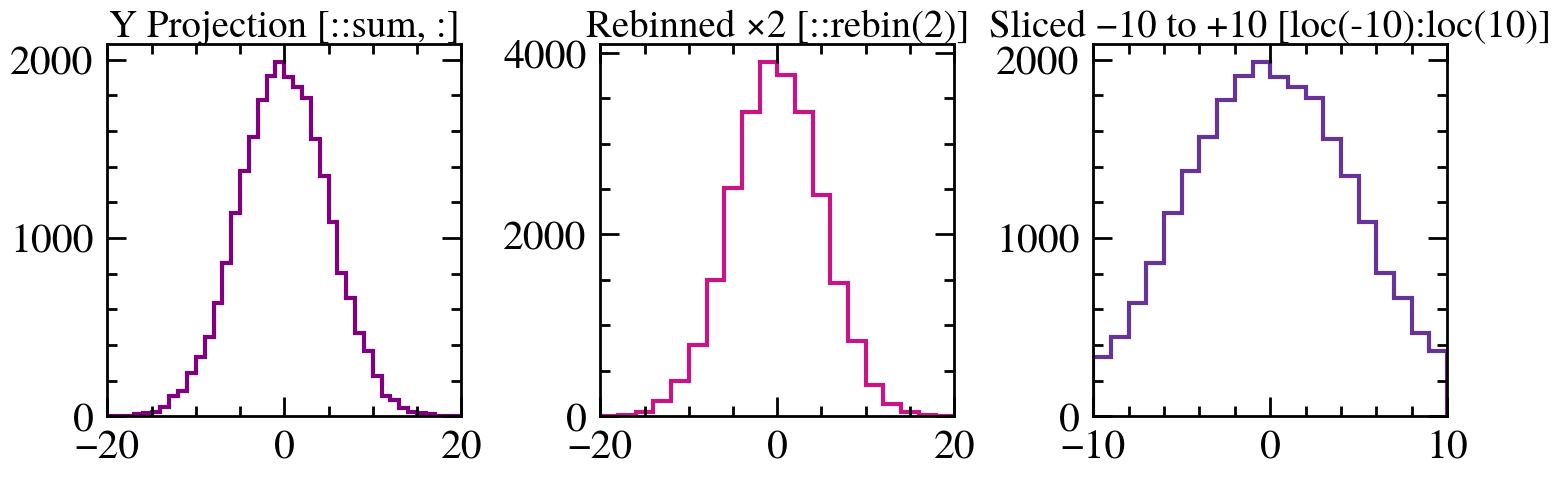

In [ ]:
# Your code here

<details>
<summary><b>Click to show solution</b></summary>

<pre>
my_projY        = h2d[::sum, :]                      # collapse X axis
my_projY_rebin2 = my_projY[::rebin(2)]               # rebin by 2
my_projY_sliced = my_projY[loc(-10):loc(10)]         # keep −10 to +10

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

hep.histplot(my_projY,        ax=axes[0], histtype="step", linewidth=3, yerr=False, color="purple")
axes[0].set_title("Y Projection  [::sum, :]")

hep.histplot(my_projY_rebin2, ax=axes[1], histtype="step", linewidth=3, yerr=False, color="mediumvioletred")
axes[1].set_title("Rebinned ×2  [::rebin(2)]")

hep.histplot(my_projY_sliced, ax=axes[2], histtype="step", linewidth=3, yerr=False, color="rebeccapurple")
axes[2].set_title("Sliced −10 to +10  [loc(-10):loc(10)]")

plt.tight_layout()
plt.show()
</pre>
</details>

---
## 📚 Further reading

- [UHI documentation](https://uhi.readthedocs.io/en/latest/)
- [ROOT UHI reference](https://root.cern.ch/doc/master/group__uhi__docs.html)
- [ROOT UHI blog post](https://root.cern/blog/uhi-for-root/)
- [ROOT histograms tutorials + UHI](https://root.cern/doc/master/group__tutorial__hist.html)
